**1. Dataset analysis**

Importing the required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from xgboost import XGBRegressor
import joblib
import os

Loading the dataset.

In [2]:
data_path = "../data/AB_NYC_2019.csv"

df = pd.read_csv(data_path)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Dataset exploration.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Analyzing the price distribution.

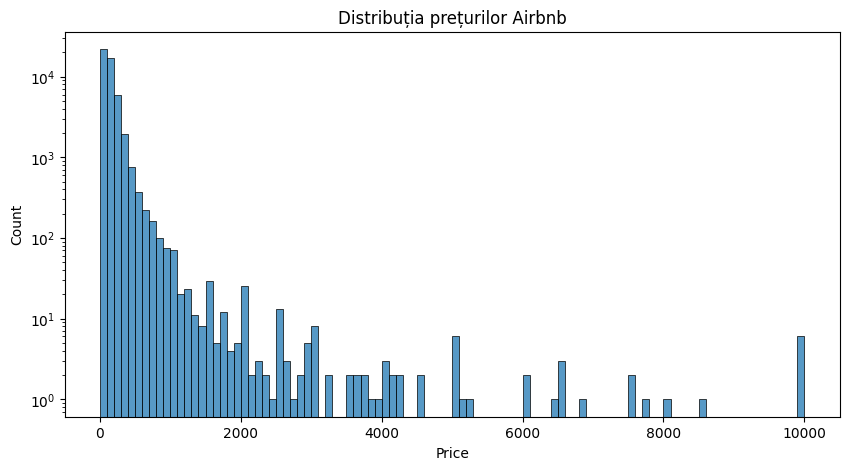

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=100, kde=False)
plt.yscale('log')
plt.xlabel('Price')
plt.title('Distribuția prețurilor Airbnb')
plt.show()

**2. Data preprocessing.**

Removing irrelevant features and handling missing or invalid values.

In [6]:
df = df.drop(columns=["id", "host_id", "name", "last_review", "host_name"])
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df = df[df["minimum_nights"]<=90]
df = df[df["price"] > 0]

Separating the target from the features.

In [7]:
X = df.drop(columns="price")
y = df["price"]

Separating the numerical and the categorical features.

In [8]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove("neighbourhood") #va fi gestionat separat

Removing extreme outliers.

In [9]:
threshold = y.quantile(0.98)

mask = y <= threshold

X = X[mask]
y = y[mask]

Splitting the dataset.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Performing a logarithmic transformation in order to limit the effect of outliers.

In [11]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Creating a custom transformer to replace the "neighbourhood column" with the average value of prices from the respective neighbourhood.

In [12]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.mappings = {}
        self.default_values = {}

    def fit(self, X, y):
        df_temp = X.copy()
        df_temp[y.name] = y
        for col in self.columns:
            df_temp[col] = df_temp[col].astype(str)
            # mapping pentru fiecare coloană
            self.mappings[col] = df_temp.groupby(col)[y.name].mean().to_dict()
            self.default_values[col] = y.mean()
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            X_copy[col] = X_copy[col].astype(str)
            X_copy[col] = X_copy[col].map(self.mappings[col]).fillna(self.default_values[col])
        return X_copy[self.columns]

Creating the preprocessing pipeline.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [col for col in numeric_features if col != 'availability_365']),
        ('availability', MinMaxScaler(), ['availability_365']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('target_encoder', TargetEncoder(columns=['neighbourhood']), ['neighbourhood'])
    ]
)

**3. Training the models**

*Linear Regression with L2 (Ridge) Regularization.*

In [14]:
LinearRegression_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

Choosing hyperparameters for Linear Regression.

In [15]:
param_dist_LR = {
    'regressor__alpha': np.logspace(-3, 3, 50)
}

random_search_LR = RandomizedSearchCV(
    LinearRegression_model,
    param_distributions=param_dist_LR,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

Training and prediction LR.

In [16]:
random_search_LR.fit(X_train, y_train_log)
best_model_LR = random_search_LR.best_estimator_
y_pred_log_LR = best_model_LR.predict(X_test)
y_pred_LR = np.expm1(y_pred_log_LR)

print("Best hyperparameters Linear Regression:", random_search_LR.best_params_)
rmse_test_LR = np.sqrt(mean_squared_error(y_test, y_pred_LR))
print("RMSE on test set for Linear Regression:", rmse_test_LR)

os.makedirs("../models", exist_ok=True)
joblib.dump(best_model_LR, "../models/LR_model.pkl")

Best hyperparameters Linear Regression: {'regressor__alpha': np.float64(8.286427728546842)}
RMSE on test set for Linear Regression: 65.28275809788681


['../models/LR_model.pkl']

*Random Forest*

In [17]:
RF_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

Choosing hyperparameters for Random Forest.

In [18]:
param_dist_RF = {
    'regressor__n_estimators': randint(50, 300),
    'regressor__max_depth': randint(5, 30),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10)
}

random_search_RF = RandomizedSearchCV(
    RF_model,
    param_distributions=param_dist_RF,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

Training and prediction RF.

In [19]:
random_search_RF.fit(X_train, y_train_log)

best_model_RF = random_search_RF.best_estimator_

y_pred_log_RF = best_model_RF.predict(X_test)
y_pred_RF = np.expm1(y_pred_log_RF)

print("Best hyperparameters Random Forest:", random_search_RF.best_params_)

rmse_test_RF = np.sqrt(mean_squared_error(y_test, y_pred_RF))
print("RMSE on test set for Random Forest:", rmse_test_RF)

joblib.dump(best_model_RF, "../models/RF_model.pkl")

Best hyperparameters Random Forest: {'regressor__max_depth': 14, 'regressor__min_samples_leaf': 3, 'regressor__min_samples_split': 13, 'regressor__n_estimators': 104}
RMSE on test set for Random Forest: 60.67996295274549


['../models/RF_model.pkl']

*XGBoost*

In [20]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42))
])

Choosing hyperparameters for XGBoost.

In [21]:
param_dist_xgb = {
    'regressor__n_estimators': [100, 200, 500],
    'regressor__max_depth': [3, 5, 7, 10],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

Training and prediction for XGBoost.

In [22]:
random_search_xgb.fit(X_train, y_train_log)

best_xgb_model = random_search_xgb.best_estimator_
y_pred_log_xgb = best_xgb_model.predict(X_test)
y_pred_xgb = np.expm1(y_pred_log_xgb)

print("Best hyperparameters for XGBoost:", random_search_xgb.best_params_)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("RMSE on test set for XGBoost:", rmse_test_xgb)

joblib.dump(best_xgb_model, "../models/XGB_model.pkl")

Best hyperparameters for XGBoost: {'regressor__subsample': 0.6, 'regressor__n_estimators': 500, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.8}
RMSE on test set for XGBoost: 60.52938860393045


['../models/XGB_model.pkl']

**4. Final Results.**

Ordering the RMSE errors achieved by the tested models.

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [rmse_test_LR, rmse_test_RF, rmse_test_xgb]
})

results = results.sort_values(by="RMSE", ascending=True).reset_index(drop=True)
results

,Model,RMSE
0,XGBoost,60.529389
1,Random Forest,60.679963
2,Linear Regression,65.282758


Plotting the true and predicted labels.

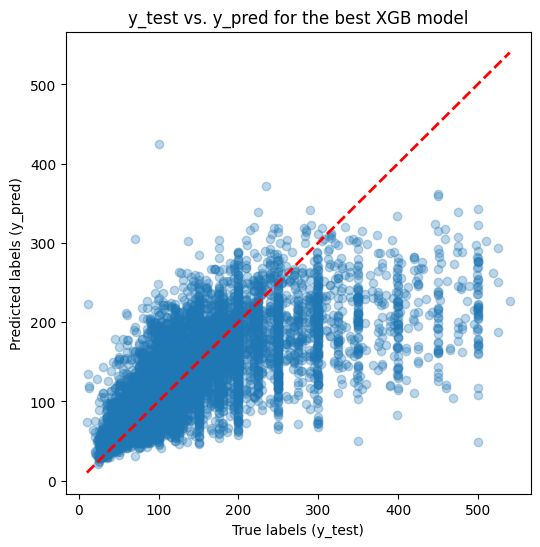

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("True labels (y_test)")
plt.ylabel("Predicted labels (y_pred)")
plt.title("y_test vs. y_pred for the best XGB model")
plt.savefig("graf_y_test_vs_y_pred.png", dpi=300, bbox_inches='tight')
plt.show()